Python ejecutable desde: c:\Users\isilva\.conda\envs\metodos\python.exe

¡NumPy funciona de 10! Matriz A_transpuesta*A simulada:
 [[2 1]
 [1 3]]


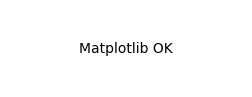

¡Entorno configurado correctamente para el TP2!


In [77]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# 1. Verificar qué Python se está ejecutando realmente
print("Python ejecutable desde:", sys.executable)

# 2. Probar que NumPy y Matplotlib respondan bien
try:
    A = np.array([[2, 1], [1, 3]])
    print("\n¡NumPy funciona de 10! Matriz A_transpuesta*A simulada:\n", A)
    
    plt.figure(figsize=(3,1))
    plt.text(0.5, 0.5, "Matplotlib OK", ha='center', va='center')
    plt.axis('off')
    plt.show()
    print("¡Entorno configurado correctamente para el TP2!")
except Exception as e:
    print(f"\nOjo, algo falló: {e}")

# Ejercicio 1: Funciones base de Bernstein
Punto C: 

Demostración Algebraica de la Partición de la Unidad

Primero desglosamos y expandimos cada uno de los polinomios:

$$b_{0}(t) = (1-t)^3 = 1 - 3t + 3t^2 - t^3$$
$$b_{1}(t) = 3(1-t)^2t = 3(1 - 2t + t^2)t = 3t - 6t^2 + 3t^3$$
$$b_{2}(t) = 3(1-t)t^2 = 3t^2 - 3t^3$$
$$b_{3}(t) = t^3$$

Después sumamos las cuatro expresiones miembro a miembro:

$$b_{0}(t) + b_{1}(t) + b_{2}(t) + b_{3}(t) = (1 - 3t + 3t^2 - t^3) + (3t - 6t^2 + 3t^3) + (3t^2 - 3t^3) + (t^3)$$

Agrupamos los términos según la potencia de $t$:

* **Término independiente:** $1$
* **Términos con $t$:** $-3t + 3t = 0$
* **Términos con $t^2$:** $3t^2 - 6t^2 + 3t^2 = 0$
* **Términos con $t^3$:** $-t^3 + 3t^3 - 3t^3 + t^3 = 0$

Y listo: al cancelarse todos los términos dependientes de $t$, llegamos al resultado final:

$$b_{0}(t) + b_{1}(t) + b_{2}(t) + b_{3}(t) = 1, \quad \forall t \in [0, 1]$$

Punto D:

Esto valida la razón por la que consideramos que la curva es una combinación convexa de los puntos de control. Sabemos que las funciones son siempre mayores o iguales a cero en el intervalo $[0,1]$ y como vimos su suma da exactamente $1$. Las funciones de base de Berstein actuan como pesos de cada punto de control y como suman 1 se refuerza esa idea de combinación convexa de puntos de control.


Le vamos a pasar 100 valores equispaciados de t a la función berstein3 del 0 al 1 y nos devuelve esta matriz:
 
[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.70002030e-01 2.96939397e-02 3.02999385e-04 1.03061015e-06]
 [9.40610059e-01 5.81820655e-02 1.19963022e-03 8.24488122e-06]
 [9.11817904e-01 8.54829285e-02 2.67134151e-03 2.78264741e-05]
 [8.83619379e-01 1.11615079e-01 4.69958229e-03 6.59590497e-05]
 [8.56008303e-01 1.36597070e-01 7.26580157e-03 1.28826269e-04]
 [8.28978490e-01 1.60447450e-01 1.03514484e-02 2.22611793e-04]
 [8.02523758e-01 1.83184771e-01 1.39379717e-02 3.53499282e-04]
 [7.76637923e-01 2.04827584e-01 1.80068206e-02 5.27672398e-04]
 [7.51314801e-01 2.25394440e-01 2.25394440e-02 7.51314801e-04]
 [7.26548208e-01 2.44903890e-01 2.75172911e-02 1.03061015e-03]
 [7.02331962e-01 2.63374486e-01 3.29218107e-02 1.37174211e-03]
 [6.78659877e-01 2.80824777e-01 3.87344520e-02 1.78089434e-03]
 [6.55525771e-01 2.97273315e-01 4.49366639e-02 2.26425050e-03]
 [6.32

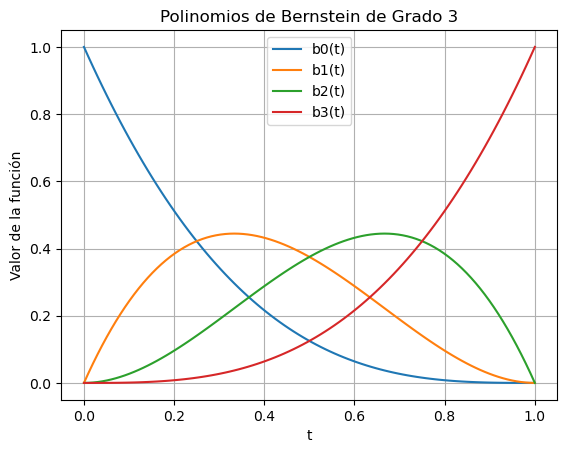

In [78]:
import numpy as np
import matplotlib.pyplot as plt

def bernstein3(t: np.ndarray) -> np.ndarray:

    b0: np.ndarray = (1 - t)**3 
    b1: np.ndarray = 3 * (1 - t)**2 * t 
    b2: np.ndarray = 3 * (1 - t) * t**2 
    b3: np.ndarray = t**3 
    
    # matriz_base es un np.ndarray, pero cambia su forma a una bidimensional de tipo (m, 4)
    matriz_base: np.ndarray = np.column_stack((b0, b1, b2, b3))
    return matriz_base

#estos son mis 100 valores de t
t_real: np.ndarray = np.linspace(0, 1, 100) 
resultado: np.ndarray = bernstein3(t_real)

print("Le vamos a pasar 100 valores equispaciados de t a la función berstein3 del 0 al 1 y nos devuelve esta matriz:")
print(" ")
print(resultado)

print("Y ahora graficamos las 4 funciones en el intervalo [0,1]")
t = np.linspace(0, 1, 100)

matriz = bernstein3(t)

# grafico cada columna. En NumPy, matriz[:, 0] significa "toda la columna 0"
plt.plot(t, matriz[:, 0], label="b0(t)")  # grafica b0
plt.plot(t, matriz[:, 1], label="b1(t)")  # grafica b1
plt.plot(t, matriz[:, 2], label="b2(t)")  # grafica b2
plt.plot(t, matriz[:, 3], label="b3(t)")  # grafica b3 

plt.title("Polinomios de Bernstein de Grado 3")
plt.xlabel("t")
plt.ylabel("Valor de la función")
plt.legend()  # muestra el cartelito de qué color es cada función
plt.grid(True) 

plt.show()

# Ejercicio 2: Evaluación matricial de una curva de Bézier

Para tener en cuenta que aprendí que en numpy np.vstack pega los arreglos uno arriba del otro (en forma de filas). Y np.column_stack pega los arreglos uno al lado del otro (en forma de columnas).

Punto D:    El producto C = AP da los puntos de la curva de Bezier

A es la matriz que tiene los valores de los 4 polinomios de Berstein evaluados en 100 valores equispaciado de t entre 0 y 1. Su dimensión es 100 filas x 4 columnas

P es la matriz de puntos de control. Cada una de las 4 filas tiene el valor de los puntos de control. En la primera columna están los valores de x y en la segunda los valores de y. 

C es la es la matriz de puntos de la curva de bezier porque multiplica cada fila de A (polinomios de berstein evaluados en 100 valores) por los valores de los puntos de control en X y en Y. Se obtiene en C una matriz con 2 columnas y 100 filas. 100 valores de X e Y para graficar la curva de Bezier.




Le vamos a pasar 100 valores equispaciados de t a la función berstein3 del 0 al 1 y nos devuelve esta matriz:
 
[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.70002030e-01 2.96939397e-02 3.02999385e-04 1.03061015e-06]
 [9.40610059e-01 5.81820655e-02 1.19963022e-03 8.24488122e-06]
 [9.11817904e-01 8.54829285e-02 2.67134151e-03 2.78264741e-05]
 [8.83619379e-01 1.11615079e-01 4.69958229e-03 6.59590497e-05]
 [8.56008303e-01 1.36597070e-01 7.26580157e-03 1.28826269e-04]
 [8.28978490e-01 1.60447450e-01 1.03514484e-02 2.22611793e-04]
 [8.02523758e-01 1.83184771e-01 1.39379717e-02 3.53499282e-04]
 [7.76637923e-01 2.04827584e-01 1.80068206e-02 5.27672398e-04]
 [7.51314801e-01 2.25394440e-01 2.25394440e-02 7.51314801e-04]
 [7.26548208e-01 2.44903890e-01 2.75172911e-02 1.03061015e-03]
 [7.02331962e-01 2.63374486e-01 3.29218107e-02 1.37174211e-03]
 [6.78659877e-01 2.80824777e-01 3.87344520e-02 1.78089434e-03]
 [6.55525771e-01 2.97273315e-01 4.49366639e-02 2.26425050e-03]
 [6.32

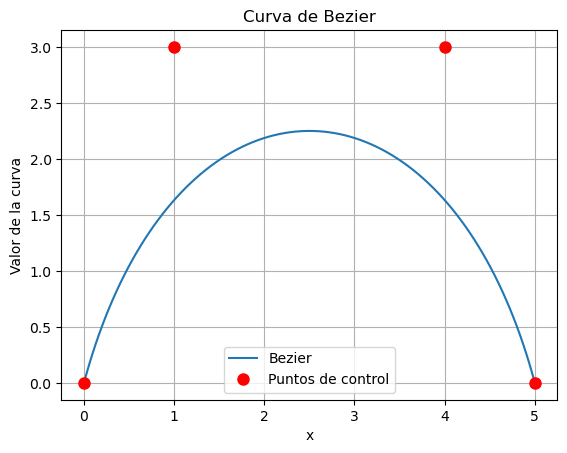

In [79]:
import numpy as np
import matplotlib.pyplot as plt

def bernstein3(t: np.ndarray) -> np.ndarray:

    b0: np.ndarray = (1 - t)**3 
    b1: np.ndarray = 3 * (1 - t)**2 * t 
    b2: np.ndarray = 3 * (1 - t) * t**2 
    b3: np.ndarray = t**3 
    
    # matriz_base es un np.ndarray, pero cambia su forma a una bidimensional de tipo (m filas, 4 columnas)
    matriz_base: np.ndarray = np.column_stack((b0, b1, b2, b3))
    return matriz_base

#estos son mis 100 valores de t
t_real: np.ndarray = np.linspace(0, 1, 100) 
A: np.ndarray = bernstein3(t_real)

print("Le vamos a pasar 100 valores equispaciados de t a la función berstein3 del 0 al 1 y nos devuelve esta matriz:")
print(" ")
print(A)

print("Ahora construyo una matriz P de dimensión 4 x 2 cuyas filas sean los puntos de control:")

def crear_matriz_puntos_control(p0, p1, p2, p3) -> np.ndarray:
   
    # apilar como filas para obtener una matriz de forma (4, 2)
    matriz_de_puntos_control: np.ndarray = np.vstack((p0, p1, p2, p3))
    return matriz_de_puntos_control

P = crear_matriz_puntos_control((0, 0), (1, 3), (4, 3), (5, 0))
print(P)

print("")
print("Ahora calculamos los puntos de la curva mediante el producto A x P = C")
print("")

def puntos_de_la_curva(A: np.ndarray, P: np.ndarray):
    C: np.ndarray = A @ P
    return C

C: np.ndarray = puntos_de_la_curva(A, P)
print(C)

plt.plot(C[:, 0], C[:, 1], label= "Bezier")  
plt.plot(P[:, 0], P[:, 1], "ro", markersize=8, label="Puntos de control")

plt.title("Curva de Bezier")
plt.xlabel("x")
plt.ylabel("Valor de la curva")
plt.legend()  # el color
plt.grid(True) 

plt.show()





# Ejercicio 3: Generación de datos con ruido



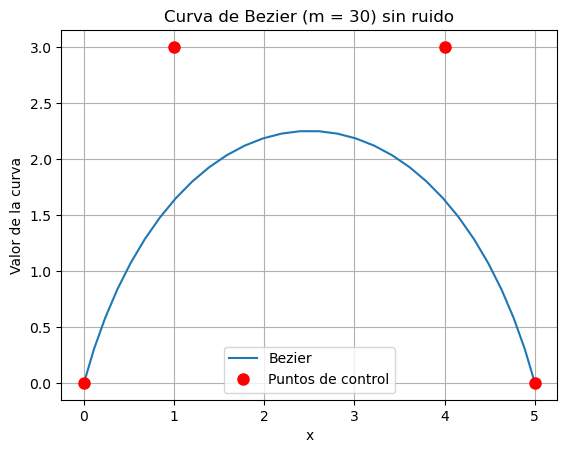

Ahora creamos la curva con ruido



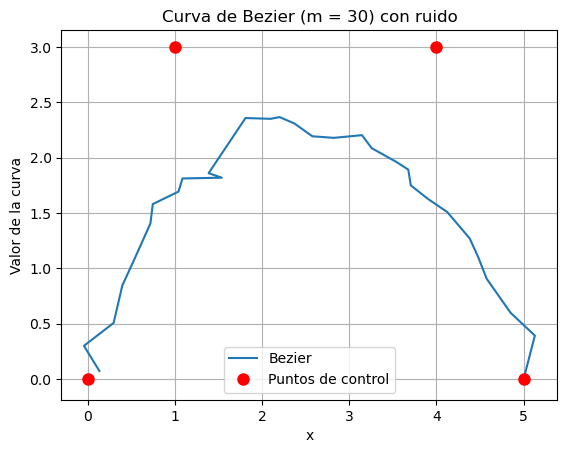

In [80]:
import numpy as np
import matplotlib.pyplot as plt

t_real: np.ndarray = np.linspace(0, 1, 30) 
A: np.ndarray = bernstein3(t_real)

P = crear_matriz_puntos_control((0, 0), (1, 3), (4, 3), (5, 0))
C: np.ndarray = puntos_de_la_curva(A, P)

plt.plot(C[:, 0], C[:, 1], label= "Bezier")  
plt.plot(P[:, 0], P[:, 1], "ro", markersize=8, label="Puntos de control")

plt.title("Curva de Bezier (m = 30) sin ruido")
plt.xlabel("x")
plt.ylabel("Valor de la curva")
plt.legend()  # el color
plt.grid(True) 

plt.show()

print("Ahora creamos la curva con ruido")
print("")
np.random.seed(10)

# loc=0.0 (media cero)
# scale=0.1 (desviación estándar, o sea, qué tan "fuerte" es el ruido)
# size=(30, 2) (porque querés un valor de ruido para cada X y cada Y de los 30 puntos)
ruido: np.ndarray = np.random.normal(loc=0.0, scale=0.1, size=(30, 2))

datos_ruidosos: np.ndarray = C + ruido

plt.plot(datos_ruidosos[:, 0], datos_ruidosos[:, 1], label= "Bezier")  
plt.plot(P[:, 0], P[:, 1], "ro", markersize=8, label="Puntos de control")

plt.title("Curva de Bezier (m = 30) con ruido")
plt.xlabel("x")
plt.ylabel("Valor de la curva")
plt.legend()  # el color
plt.grid(True) 

plt.show()




# Ejercicio 4: Ajuste de una curva de Bézier por mínimos cuadrados

AP son los puntos de la curva de Bezier a graficar, siendo A la matriz de las funciones de Berstein evaluadas en m=30 valores equispaciados entre 0 y 1 y P los puntos de control (dimensión 4*2). Pero en el ejercicio anterior generamos puntos con ruido gaussiano. Esos puntos ruidosos son Q= AP + ruido. Como hay ruido, Q no está exactamente sobre ninguna curva de Bézier. Queremos encontrar la P̂ tal que AP̂ sea la curva que mejor se aproxima a esos puntos ruidosos. Es decir que AP̂ sea lo mas parecida a Q. Eso es exactamente mínimos cuadrados. 

Investigamos y descubrimos que ‖AP - Q‖² es simplemente la raíz cuadrada de la suma de todos los elementos al cuadrado. $$\|AP - Q\|_F^2 = \sum_{i,j} (AP - Q)_{ij}^2$$

**Por qué esto se reduce a mínimos cuadrados**

Vimos que Q tiene 2 columnas, y P también tiene 2 columnas. Si llamamos q₁, q₂ a las columnas de Q, y p₁, p₂ a las de P:

$$\|AP - Q\|_F^2 = \|Ap_1 - q_1\|^2 + \|Ap_2 - q_2\|^2$$

O sea, el problema se separa en dos problemas de mínimos cuadrados independientes, uno por cada columna. Cada uno tiene la forma clásica que ya conocemos: minimizar ‖Ax - b‖².
La solución de cada uno es la ecuación normal:

$$A^T A \hat{p}_i = A^T q_i$$

Y como ambos comparten la misma A, lo resolvimos juntos como un solo sistema matricial:

$$A^T A \hat{P} = A^T Q$$

Comparación entre los puntos de control originales y los puntos de control estimados (punto e): No son exactamente iguales porque la curva que tiene esos puntos intentará acercarse lo mas posible a los puntos observados con ruido no a los puntos de la curva de bezier original. Si ese hubiese sido el caso al hacer cuadrados mínimos habríamos obtenido la matriz P con los puntos de control originales. Es decir, solo si el ruido fuera cero (σ = 0), recuperaríamos exactamente los puntos de control originales. 

Qué ocurre cuando aumenta el nivel de ruido (punto i): A medida que aumenta el nivel de ruido la curva ajustada no pierde su forma original. En cambio, sus puntos de control estimados son cada vez mas diferentes a los de la curva original. 

Sabemos que la curva de Bézier en cada punto t es un promedio ponderado de los 4 puntos de control (eso es lo que hacen los polinomios de Bernstein). Entonces cuando mínimos cuadrados ajusta la curva a 30 puntos ruidosos, el ruido de esos 30 puntos se promedia a lo largo de toda la curva. Porque si el ruido es gaussiano con media cero, esa suma tiende a cancelarse, unos positivos, otros negativos. Eso es el promedio.
Pero los 4 puntos de control tienen que cargar solos con todo el ajuste. Para que AP̂ se acerque a Q punto a punto, P̂ se tiene que mover bastante respecto a P. Cuanto mayor es σ, más dispersos están los 30 puntos ruidosos, y más tienen que moverse los puntos de control para compensar aunque la curva final igual se vea razonable porque los errores se siguen promediando.


Acá está el P sombrero que minimiza la expresión ||AP - Q||**2:

[[ 0.05064689 -0.06943931]
 [ 0.89111267  3.17213596]
 [ 4.08059359  2.83194426]
 [ 5.0192952  -0.03759889]]

Y acá lo resolvimos usando la forma de la ecuación normal: (nos dio lo mismo)

[[ 0.05064689 -0.06943931]
 [ 0.89111267  3.17213596]
 [ 4.08059359  2.83194426]
 [ 5.0192952  -0.03759889]]


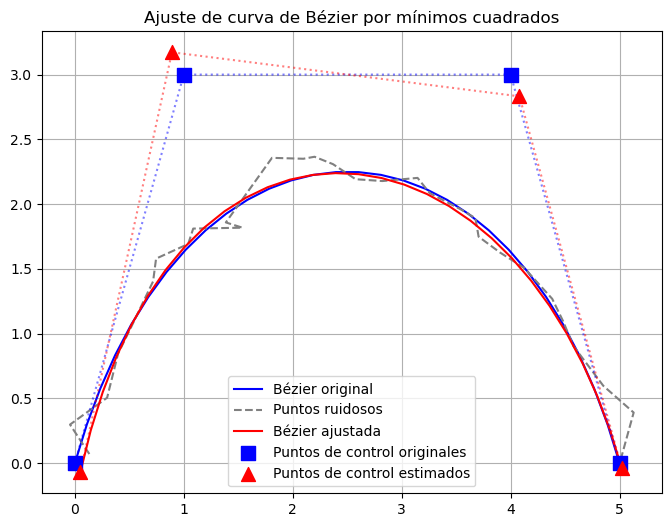

Repetimos el procedimiento anterior para distintos niveles de ruido.


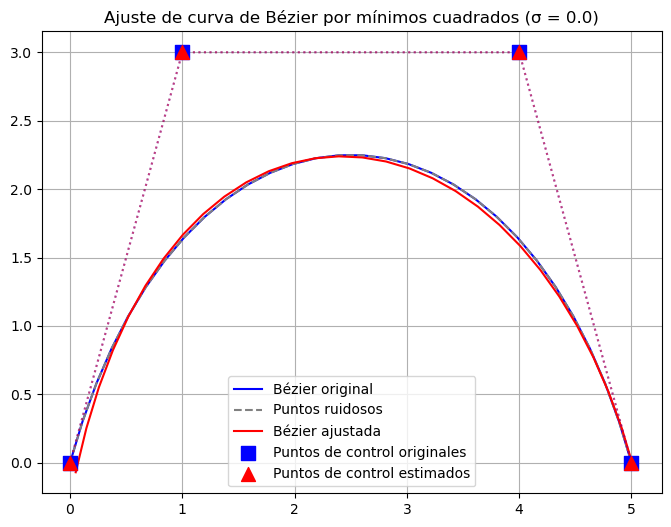

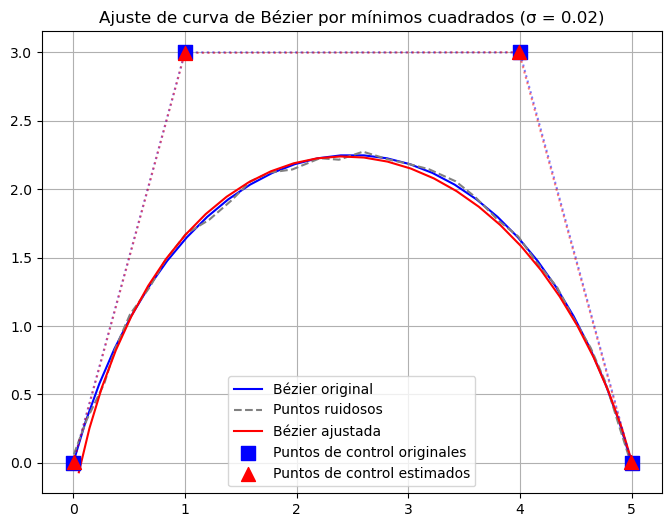

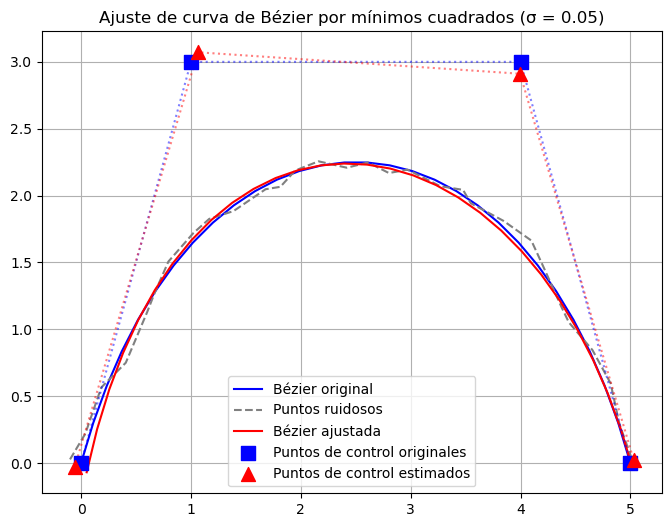

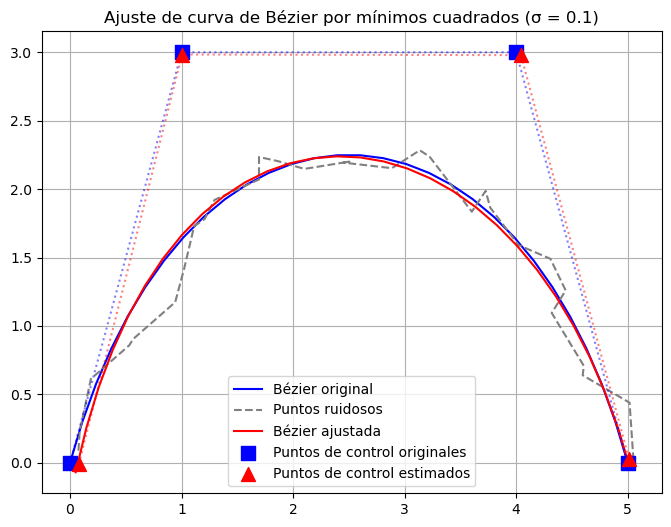

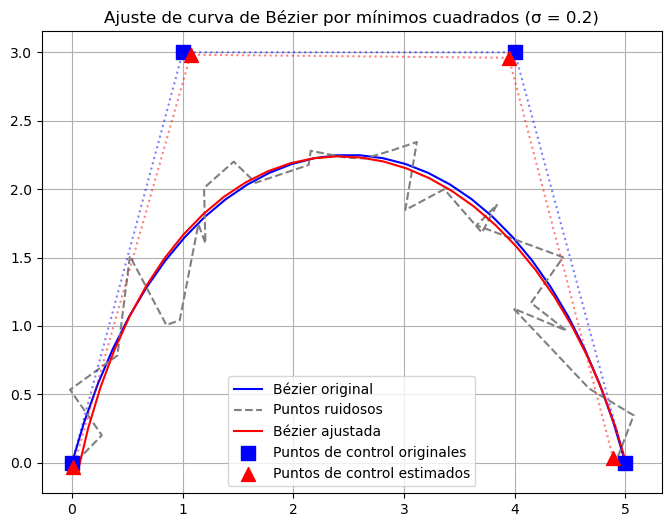

sigma=0.0  ECM=0.000000
sigma=0.02  ECM=0.000019
sigma=0.05  ECM=0.000697
sigma=0.1  ECM=0.001651
sigma=0.2  ECM=0.003044


In [81]:
import numpy as np
import matplotlib.pyplot as plt

t_real: np.ndarray = np.linspace(0, 1, 30)
A: np.ndarray = bernstein3(t_real)

ruido: np.ndarray = np.random.normal(loc=0.0, scale=0.1, size=(30, 2))
P = crear_matriz_puntos_control((0, 0), (1, 3), (4, 3), (5, 0))

Q: np.ndarray = A @ P + ruido

# A es tu matriz de m x 4, Q es nuestra matriz de m x 2
# lstsq resuelve mínimos cuadrados columna a columna y devuelve la P̂ de 4×2 directamente.
P_sombrero: np.ndarray = np.linalg.lstsq(A, Q, rcond=None)[0]

print ("Acá está el P sombrero que minimiza la expresión ||AP - Q||**2:")
print ("")
print (P_sombrero)
print ("")
print ("Y acá lo resolvimos usando la forma de la ecuación normal: (nos dio lo mismo)")
print ("")

P_sombrero_ecuación_normal = np.linalg.inv(A.T @ A) @ A.T @ Q
print (P_sombrero_ecuación_normal)
fig, ax = plt.subplots(figsize=(8, 6))

# Curvas
ax.plot(C[:, 0], C[:, 1], color='blue', label='Bézier original')
ax.plot(datos_ruidosos[:, 0], datos_ruidosos[:, 1], color='gray', linestyle='--', label='Puntos ruidosos')
ax.plot((A @ P_sombrero)[:, 0], (A @ P_sombrero)[:, 1], color='red', label='Bézier ajustada')

# Puntos de control originales
ax.scatter(P[:, 0], P[:, 1], color='blue', marker='s', s=100, zorder=5, label='Puntos de control originales')
ax.plot(P[:, 0], P[:, 1], color='blue', linestyle=':', alpha=0.5)

# Puntos de control estimados
ax.scatter(P_sombrero[:, 0], P_sombrero[:, 1], color='red', marker='^', s=100, zorder=5, label='Puntos de control estimados')
ax.plot(P_sombrero[:, 0], P_sombrero[:, 1], color='red', linestyle=':', alpha=0.5)

ax.legend()
ax.set_title('Ajuste de curva de Bézier por mínimos cuadrados')
ax.grid(True)
plt.show()
 

print("Repetimos el procedimiento anterior para distintos niveles de ruido.")

sigmas = [0.00, 0.02, 0.05, 0.10, 0.20]
ecms = []
for sigma in sigmas:  
    fig, ax = plt.subplots(figsize=(8, 6))
    ruido_punto_f: np.ndarray = np.random.normal(loc=0.0, scale=sigma, size=(30, 2))
    Q_punto_f: np.ndarray = A @ P + ruido_punto_f
    #Resuelvo m[inimos cuadrados para esa Q con ruido 
    P_sombrero_punto_f: np.ndarray = np.linalg.lstsq(A, Q_punto_f, rcond=None)[0]
    ecms:list
    ecm = (1/30) * np.sum(np.linalg.norm(C - A @ P_sombrero_punto_f, axis=1)**2)
    ecms.append(ecm)
    # Curvas
    ax.plot(C[:, 0], C[:, 1], color='blue', label='Bézier original')
    ax.plot(Q_punto_f[:, 0], Q_punto_f[:, 1], color='gray', linestyle='--', label='Puntos ruidosos')
    ax.plot((A @ P_sombrero)[:, 0], (A @ P_sombrero)[:, 1], color='red', label='Bézier ajustada')

    # Puntos de control originales
    ax.scatter(P[:, 0], P[:, 1], color='blue', marker='s', s=100, zorder=5, label='Puntos de control originales')
    ax.plot(P[:, 0], P[:, 1], color='blue', linestyle=':', alpha=0.5)

    # Puntos de control estimados
    ax.scatter(P_sombrero_punto_f[:, 0], P_sombrero_punto_f[:, 1], color='red', marker='^', s=100, zorder=5, label='Puntos de control estimados')
    ax.plot(P_sombrero_punto_f[:, 0], P_sombrero_punto_f[:, 1], color='red', linestyle=':', alpha=0.5)

    ax.legend()
    ax.set_title(f'Ajuste de curva de Bézier por mínimos cuadrados (σ = {sigma})')
    ax.grid(True)
    plt.show()
    
for sigma, ecm in zip(sigmas, ecms):
    print(f"sigma={sigma}  ECM={ecm:.6f}")

# Ejercicio 5: La función de error como forma cuadrática

¿Qué sugiere el hecho de que todos los autovalores de $A^T$A sobre la forma de la función de error?

Lo que sugieren los autovalores positivos es que la parte cuadrática $p^\top A^\top A p$ es definida positiva, lo que garantiza que E(p) tiene forma de "cuenco". Ahí hay un único mínimo global, sin mínimos locales ni direcciones planas.

Lo pensamos en 1D primero. Una función de la forma:

$$f(x) = ax^2 - bx + c$$

con $a > 0$ siempre tiene forma de parábola con mínimo único, sin importar cuánto valen $b$ y $c$. El $b$ inclina la parábola, el $c$ la sube o baja, pero la **curvatura** (que determina que sea un cuenco) la da solo el $a$.

Después vimos que en múltiples dimensiones es lo mismo. $E(p)$ tiene la forma:

$$E(p) = \underbrace{p^\top A^\top A p  } _ {\text{curvatura}} \underbrace{ - 2q^\top Ap}_{\text{inclinación}} + \underbrace{q^\top q}_{\text{constante}}$$

El término cuadrático $p^\top A^\top A p$ con autovalores positivos garantiza que la función curva hacia arriba en todas las direcciones. El término lineal $-2q^\top Ap$ solo desplaza el punto donde está el mínimo, pero no puede crear un segundo mínimo ni aplanar la función. La constante $q^\top q$ solo sube o baja toda la función.





In [82]:
import numpy as np
import matplotlib.pyplot as plt

print (np.allclose(A.T @ A, (A.T @ A).T))
print ("$A^T$A es simétrica")

eigenvalues, eigenvectors = np.linalg.eig(A.T @ A)

#hacer un if, si es no simetrica es false
print(eigenvalues)

True
$A^T$A es simétrica
[7.51154315 4.8161144  1.70568592 0.25824389]


# Ejercicio 6: La función de error como forma cuadrática

Veamos como imponer $\nabla E(p) = 0$ conduce a las ecuaciones normales: $A^T Ap = A^T q$. (Punto e)

$$\nabla E(p) = 2A^T(Ap - q)$$

El mínimo de una función se encuentra donde la derivada es cero:

$$2A^T(Ap - q) = 0$$

Dividimos por 2 y distribuimos:

$$A^T Ap - A^T q = 0$$

$$A^T Ap = A^T q$$

Ahí aparecen las ecuaciones normales.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gradiente(p, A, q) -> np.ndarray:
    p = np.asarray(p)
    # grad E(p) = 2 * A^T (A p - q)
    res = 2 * (A.T @ (A @ p - q))
    return res

print("Evaluamos el gradiente en un vector inicial cualquiera, por ejemplo p = (0, 0, 0, 0)")
print("")
print (gradiente ([0,0,0,0], A, Q[:, 0]))
print("")
print("Y ahora evaluamos el gradiente en la solución de mínimos cuadrados P sombrero (le pasamos los x de P)")
print("")
print(gradiente (P_sombrero_ecuación_normal[:, 0], A, Q[:, 0]))
print("")
print("Veamos si el gradiente en la solucion de MC es aproximadamente cero")
print("")

if (np.allclose(gradiente(P_sombrero_ecuación_normal[:, 0], A, Q[:, 0]), 0)):
    print (True)
else :
    print (False)




Evaluamos el gradiente en un vector inicial cualquiera, por ejemplo p = (0, 0, 0, 0)

[-12.98996725 -28.17151455 -44.40058241 -65.11347262]

Y ahora evaluamos el gradiente en la solución de mínimos cuadrados P sombrero (le pasamos los x de P)

[-6.68822985e-15  9.80530584e-15  7.16547349e-15 -3.70883879e-15]

Veamos si el gradiente en la solucion de MC es aproximadamente cero

True
